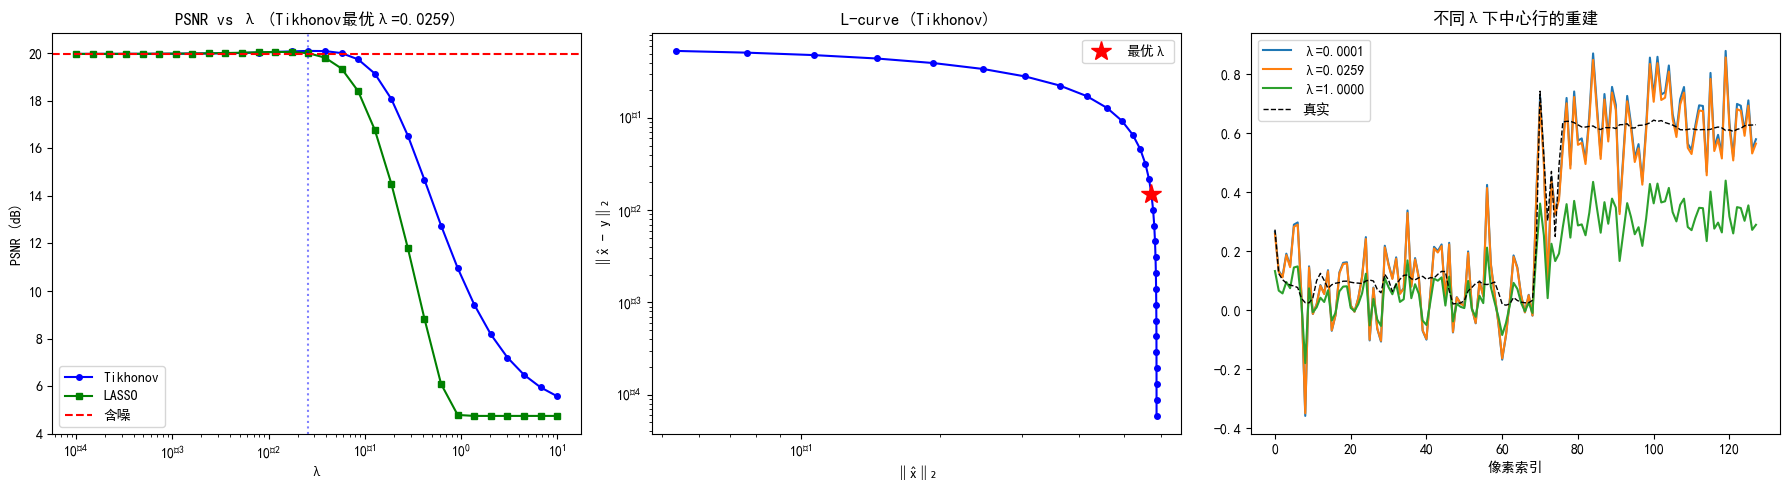

In [2]:
"""
实验2.2 正则化参数λ对重建的影响
对应章节：2.1 / 2.2
知识点：λ = σ²/σ_x²；过拟合 vs 过正则化；L-curve

素材来源：
  - M1 CompImLab25.ipynb: Tikhonov闭式解 + LASSO软阈值 + PSNR度量
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ====== 来源: M1 (CompImLab25.ipynb) ======

n = 128
x = resize(data.camera(), (n, n))

# 加噪
noise_lev = 1e-1
y = x + noise_lev * np.random.randn(n, n)

# M1: soft_thresh 函数
def soft_thresh(x, l):
    """软阈值函数 (来源: M1)"""
    return np.multiply(np.sign(x), np.maximum(np.abs(x) - l, np.zeros_like(x)))

# 扫描 lambda
lambdas = np.logspace(-4, 1, 30)
psnr_tikh = []
psnr_lasso = []
res_norm_tikh = []
sol_norm_tikh = []

for lam in lambdas:
    # Tikhonov 闭式解 (M1: x_Tikh = y/(1+lambda_Tikh))
    x_tikh = y / (1 + lam)
    psnr_tikh.append(peak_signal_noise_ratio(x, x_tikh))
    res_norm_tikh.append(np.sqrt(np.mean((x_tikh - y)**2)))
    sol_norm_tikh.append(np.sqrt(np.mean(x_tikh**2)))

    # LASSO 软阈值 (M1: x_Lasso = soft_thresh(y, lambda_Lasso))
    x_lasso = soft_thresh(y, lam)
    psnr_lasso.append(peak_signal_noise_ratio(x, x_lasso))

best_idx = np.argmax(psnr_tikh)

# ====== 可视化 ======
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) PSNR vs lambda
axes[0].semilogx(lambdas, psnr_tikh, 'b-o', markersize=4, label='Tikhonov')
axes[0].semilogx(lambdas, psnr_lasso, 'g-s', markersize=4, label='LASSO')
axes[0].axhline(y=peak_signal_noise_ratio(x, y), color='r', linestyle='--', label='含噪')
axes[0].axvline(x=lambdas[best_idx], color='b', linestyle=':', alpha=0.5)
axes[0].set_xlabel('λ')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title(f'PSNR vs λ (Tikhonov最优λ={lambdas[best_idx]:.4f})')
axes[0].legend()

# (b) L-curve
axes[1].loglog(sol_norm_tikh, res_norm_tikh, 'b-o', markersize=4)
axes[1].plot(sol_norm_tikh[best_idx], res_norm_tikh[best_idx], 'r*', markersize=15, label='最优λ')
axes[1].set_xlabel('‖x̂‖₂')
axes[1].set_ylabel('‖x̂ - y‖₂')
axes[1].set_title('L-curve (Tikhonov)')
axes[1].legend()

# (c) 不同 lambda 下的重建 (中心行)
for lam_val in [1e-4, lambdas[best_idx], 1.0]:
    x_tikh = y / (1 + lam_val)
    axes[2].plot(x_tikh[n//2, :], linewidth=1.5, label=f'λ={lam_val:.4f}')
axes[2].plot(x[n//2, :], 'k--', linewidth=1, label='真实')
axes[2].set_title('不同λ下中心行的重建')
axes[2].legend()
axes[2].set_xlabel('像素索引')

plt.tight_layout()
plt.savefig('2_2_result.png', dpi=150, bbox_inches='tight')
plt.show()
